In [2]:
import warnings
warnings.filterwarnings("ignore")
from pathlib import Path
import joblib
import kagglehub
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression, SGDRegressor
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score,
)

plt.style.use("ggplot")
pd.set_option("display.max_columns", None)

In [3]:
dataset_path = Path(
    kagglehub.dataset_download(
        "alamshihab075/health-and-lifestyle-data-for-diabetes-prediction"
    )
)

In [4]:
csv_file = next(dataset_path.glob("*.csv"))
df = pd.read_csv(csv_file)
df.head()

,Age,gender,ethnicity,education_level,income_level,employment_status,smoking_status,alcohol_consumption_per_week,physical_activity_minutes_per_week,diet_score,sleep_hours_per_day,screen_time_hours_per_day,family_history_diabetes,hypertension_history,cardiovascular_history,bmi,waist_to_hip_ratio,systolic_bp,diastolic_bp,heart_rate,cholesterol_total,hdl_cholesterol,ldl_cholesterol,triglycerides,glucose_fasting,glucose_postprandial,insulin_level,hba1c,diabetes_risk_score,diabetes_stage,diagnosed_diabetes
0,58,Male,Asian,Highschool,Lower-Middle,Employed,Never,0,215,5.7,7.9,7.9,0,0,0,30.5,0.89,134,78,68,239,41,160,145,136,236,6.36,8.18,29.6,Type 2,1
1,52,Female,White,Highschool,Middle,Employed,Former,1,143,6.7,6.5,8.7,0,0,0,23.1,0.80,129,76,67,116,55,50,30,93,150,2.00,5.63,23.0,No Diabetes,0
2,60,Male,Hispanic,Highschool,Middle,Unemployed,Never,1,57,6.4,10.0,8.1,1,0,0,22.2,0.81,115,73,74,213,66,99,36,118,195,5.07,7.51,44.7,Type 2,1
3,74,Female,Black,Highschool,Low,Retired,Never,0,49,3.4,6.6,5.2,0,0,0,26.8,0.88,120,93,68,171,50,79,140,139,253,5.28,9.03,38.2,Type 2,1
4,46,Male,White,Graduate,Middle,Retired,Never,1,109,7.2,7.4,5.0,0,0,0,21.2,0.78,92,67,67,210,52,125,160,137,184,12.74,7.20,23.5,Type 2,1


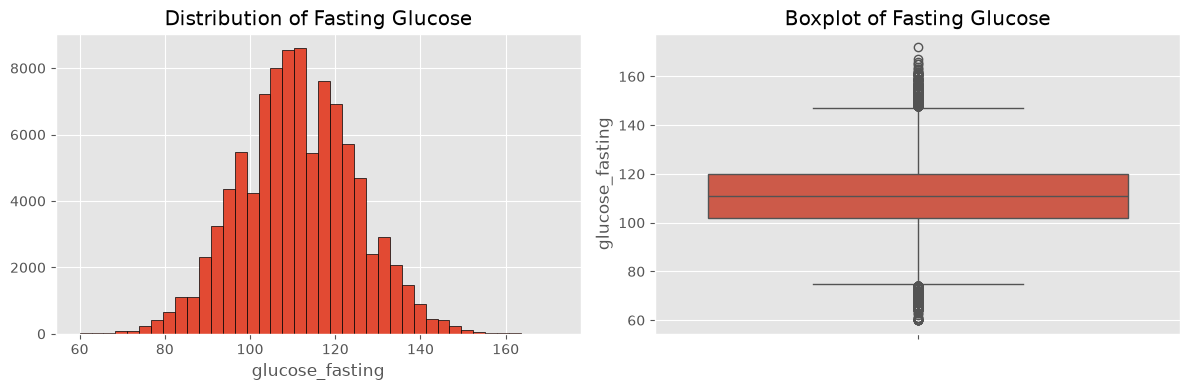

In [5]:
TARGET = "glucose_fasting"

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].hist(df[TARGET], bins=40, edgecolor="black")
axes[0].set_title("Distribution of Fasting Glucose")
axes[0].set_xlabel(TARGET)

sns.boxplot(y=df[TARGET], ax=axes[1])
axes[1].set_title("Boxplot of Fasting Glucose")
plt.tight_layout()
plt.show()

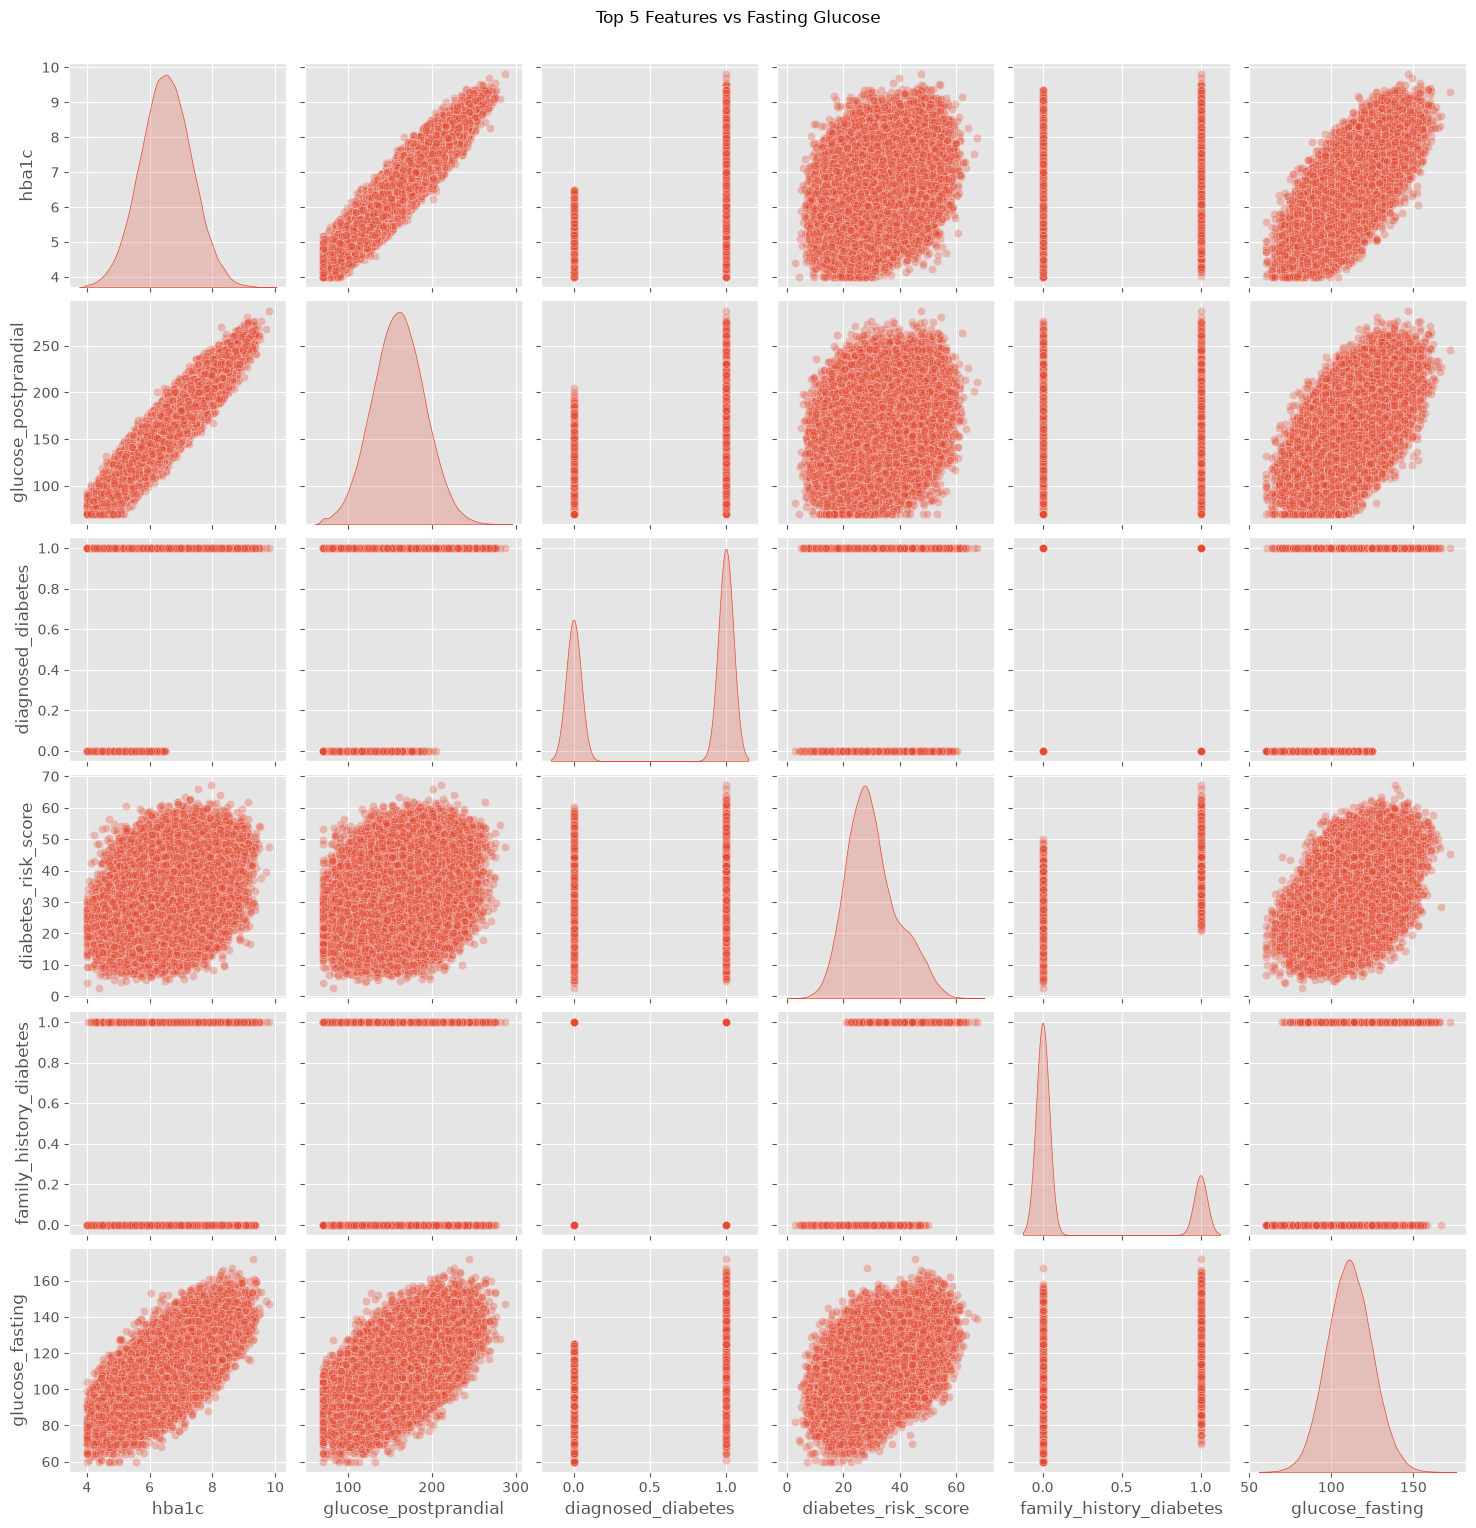

In [6]:
top_feats = (
    df.select_dtypes(include='number')
    .corr()[TARGET]
    .drop(TARGET)
    .abs()
    .nlargest(5)
    .index.tolist()
)

sns.pairplot(df[top_feats + [TARGET]], diag_kind="kde", plot_kws={"alpha": 0.3})
plt.suptitle("Top 5 Features vs Fasting Glucose", y=1.02)
plt.show()

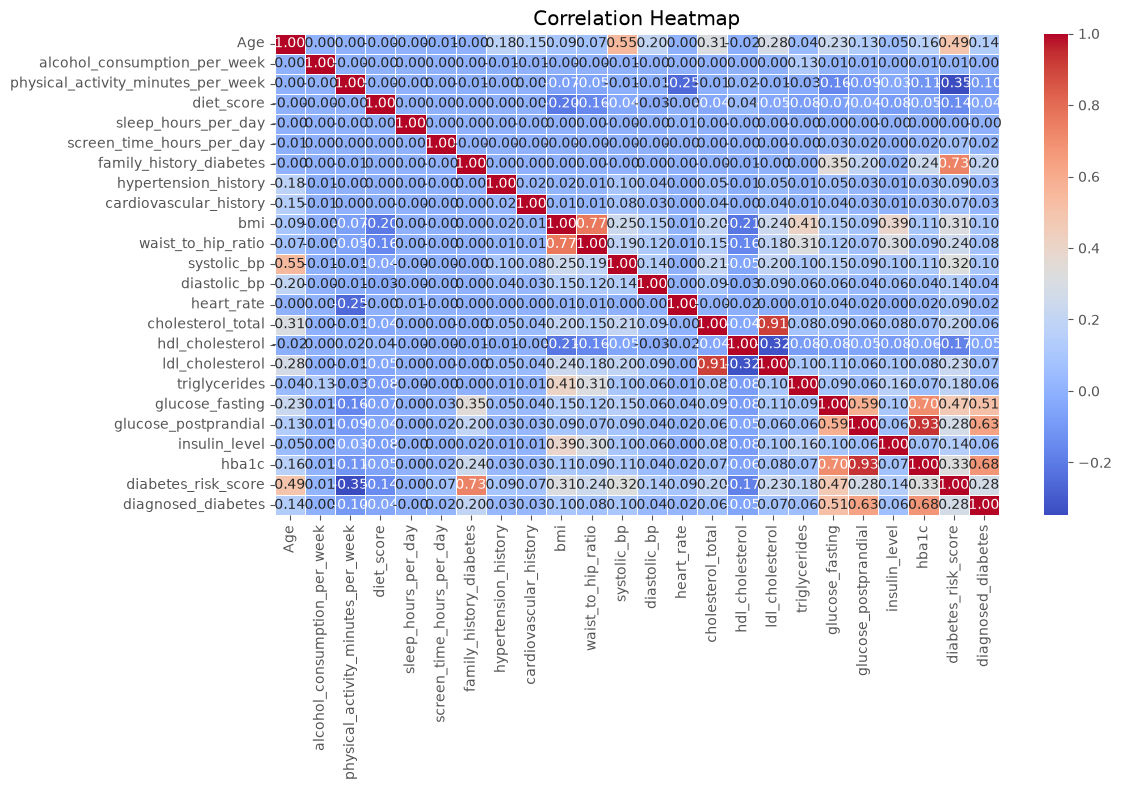

In [7]:
num_cols = df.select_dtypes(include=np.number).columns.tolist()
corr = df[num_cols].corr()

plt.figure(figsize=(12, 8))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", linewidths=0.5)
plt.title("Correlation Heatmap")
plt.tight_layout()
plt.show()

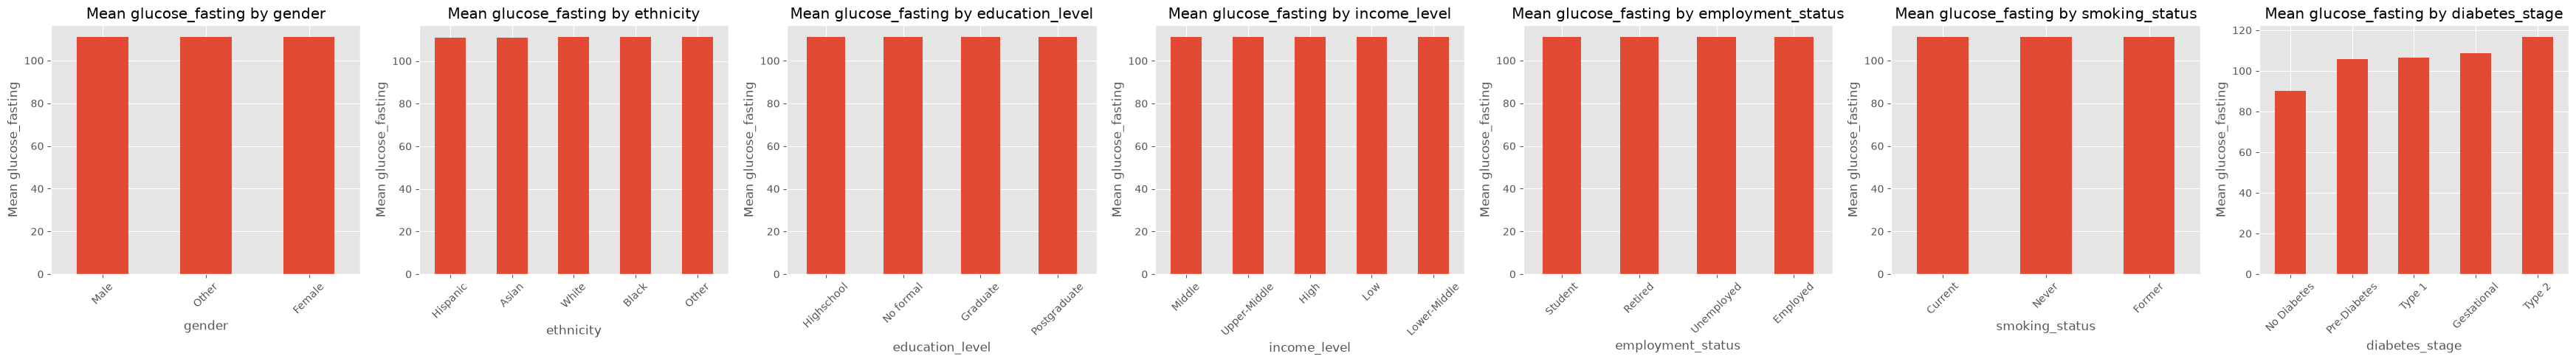

In [8]:
cat_cols = df.select_dtypes(include='object').columns.tolist()

n = len(cat_cols)
fig, axes = plt.subplots(1, n, figsize=(5 * n, 5))
if n == 1:
    axes = [axes]

for ax, col in zip(axes, cat_cols):
    df.groupby(col)[TARGET].mean().sort_values().plot(kind='bar', ax=ax)
    ax.set_title(f'Mean {TARGET} by {col}')
    ax.set_xlabel(col)
    ax.set_ylabel(f'Mean {TARGET}')
    ax.tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()


In [9]:
LEAKAGE = ["diagnosed_diabetes", "diabetes_stage", "diabetes_risk_score"]
df = df.drop(columns=LEAKAGE).dropna()
print(df.shape)
print(df.isnull().sum())


(97297, 28)
Age                                   0
gender                                0
ethnicity                             0
education_level                       0
income_level                          0
employment_status                     0
smoking_status                        0
alcohol_consumption_per_week          0
physical_activity_minutes_per_week    0
diet_score                            0
sleep_hours_per_day                   0
screen_time_hours_per_day             0
family_history_diabetes               0
hypertension_history                  0
cardiovascular_history                0
bmi                                   0
waist_to_hip_ratio                    0
systolic_bp                           0
diastolic_bp                          0
heart_rate                            0
cholesterol_total                     0
hdl_cholesterol                       0
ldl_cholesterol                       0
triglycerides                         0
glucose_fasting             

In [10]:
X = df.drop(columns=["glucose_fasting"])
y = df["glucose_fasting"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(X_train.shape, X_test.shape)


(77837, 27) (19460, 27)


In [11]:
X = df.drop(columns=["glucose_fasting"])
y = df["glucose_fasting"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(X_train.shape, X_test.shape)


(77837, 27) (19460, 27)
